# TP06 Dask Array
# Distance de Levenstein

La distance de Levenshtein est une métrique permettant de mesurer la différence entre deux séquences de caractères. Cette distance correspond au nombre minimal d'opérations élémentaires (insertion, suppression ou substitution de caractères) nécessaires pour transformer une séquence en une autre.

Par exemple, la distance entre `sitting` et `kitten` est de 3 (2 substitutions, 1 suppression).

Formellement, la distance peut être définie de manière récursive selon la définition suivante où pour une chaîne de caractères $s$, $|s|$ représente sa longueur et $s-1$ désigne la chaîne $s$ sans son premier caractère.
$$
\qquad\operatorname{lev}(a,b) = 
\begin{cases}
  \max(|a|,|b|) & \text{ si } \min(|a|,|b|)=0, \\
  \operatorname{lev}(a-1,b-1) & \text{ si } a[0]=b[0], \\
  1 + \min \begin{cases}
          \operatorname{lev}(a-1,b)\\
          \operatorname{lev}(a,b-1)\\
          \operatorname{lev}(a-1,b-1)
       \end{cases} & \text{ sinon.}
\end{cases}
$$

À partir de cette définition, il en résulte un algorithme itératif dynamique naïf permettant de calculer la distance de Levenshtein entre deux séquences en remplissant une matrice de coûts (matrice d'édition).

L’objectif de cet exercice est d’établir un algorithme distribué du calcul de la distance de Levenshtein et, si possible, de le mettre en oeuvre avec Dask

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt
import dask.array as da
# from numba import njit

In [3]:
def initialize_matrix(s1, s2):
    """Initialisation de la matrice d'édition avec les bords (insertions/suppressions)."""
    m, n = len(s1), len(s2)

    # Création de la matrice principale
    dp = np.zeros((m+1, n+1), dtype=int)

    # Initialisation des bords (coûts d'insertion et suppression)
    dp[:, 0] = np.arange(m+1)  # Première colonne : Suppressions
    dp[0, :] = np.arange(n+1)  # Première ligne : Insertions

    return dp

In [4]:
def fill_matrix(dp, s1, s2):
    """Remplissage la matrice de Levenshtein (approche dynamique)"""
    m, n = len(s1), len(s2)

    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            dp[i, j] = min(
                dp[i-1, j] + 1,      # Suppression
                dp[i, j-1] + 1,      # Insertion
                dp[i-1, j-1] + cost  # Substitution
            )

In [5]:
def levenshtein_numpy(s1, s2):
    """Calcul de la distance levenshtein."""
    dp = initialize_matrix(s1, s2)  # Initialisation de la matrice
    fill_matrix(dp, s1, s2)         # Remplissage de la matrice
   
    return dp[len(s1), len(s2)]     # Retourne la distance finale

### Test

In [6]:
s1 = "GATTACA"
s2 = "GCATGCU"
print(levenshtein_numpy(s1, s2))  

4


## 1. Version naïve.
1. Tester l’algorithme sur différentes séquences en augmentant la taille des séquences et relever les temps de restitution.

In [7]:
sequences1 = [
    'GATTACA', 'flawn', 'sitting', 'saturday', 'elephant', 'encyclopedia', 'democracy', 'marcy', 'rodrigo',
    'pneumonoultramicroscopicsilicovolcanoconiosis', 'hepaticocholangiocholecystenterostomies', 
    'supercalifragilisticexpialidocious', 'pseudopseudohypoparathyroidism', 'floccinaucinihilipilification',
    'algorithm', 'basketball', 'chocolate', 'diamond', 'elephant', 'freedom', 'giraffe', 'happiness', 
    'illusion', 'jazz', 'kangaroo', 'lightning', 'mountain', 'notebook', 'octopus', 'penguin', 'quasar',
    'butterfly', 'crocodile', 'dinosaur', 'fireworks', 'hamburger', 'kaleidoscope', 'lighthouse', 
    'metamorphosis', 'nightingale', 'orchestra',
    'internationalization', 'confidentiality', 'incomprehensible', 'biodegradability', 'characterization', 
    'electromagnetic', 'industrialization', 'revolutionary', 'telecommunication', 'unpredictability',
    'counterrevolutionary', 'deinstitutionalization', 'electroencephalogram', 'institutionalization', 
    'overcommercialization', 'psychophysiological', 'radioimmunoassay', 'thermoluminescence', 
    'trichotillomania', 'uncharacteristically'
]

sequences2 = [
    'GCATGCU', 'kitten', 'sunday', 'relevant', 'psychoanalysis', 'aristocracy', 'andreina', 'gaston',
    'antidisestablishmentarianism', 'honorificabilitudinitatibus', 'thyroparathyroidectomized', 
    'dichlorodifluoromethane', 'incomprehensibilities', 'alligator', 'basket', 'caramel', 'dynamite', 
    'elephant', 'festival', 'guitar', 'harmony', 'imagination', 'jungle', 'koala', 'lighthouse', 'monument', 
    'notepad', 'ostrich', 'parrot', 'quicksand', 'buttercup', 'crocodile', 'dinosaur', 'firework', 
    'hamburgers', 'kaleidoscopes', 'lantern', 'metamorphic', 'nightmare', 'orchestral',
    'intercontinental', 'confidential', 'incomprehensibly', 'biodegradable', 'characteristic', 
    'electromagnetism', 'industrialized', 'revolutionize', 'telecommunications', 'unpredictable',
    'counterproductive', 'deinstitutionalize', 'electroencephalograph', 'institutionalize', 
    'overcommercialize', 'psychophysiologic', 'radioimmunological', 'thermoluminescent', 
    'trichotillomaniac', 'uncharacteristic', 'drawn'
]

restitutions_times_numpy = [] #Tableau qui stocke le temps de restitution entre deux mots

levenshtein_distances = [] #Tableau qui stocke la distance de Levenshtein entre deux mots

distances_words = [] #Tablau qui stocke ma matrice de cellules entre deux mots
for index,(mot1,mot2) in enumerate(zip(sequences1, sequences2)):
    tic = time.time()
    levenshtein_distance = levenshtein_numpy(mot1, mot2)
    toc =  time.time()
    temps = (toc-tic)
    restitutions_times_numpy.append(temps)
    distances_words.append((len(mot1)+1)*(len(mot2)+1))
    levenshtein_distances.append(levenshtein_distance)



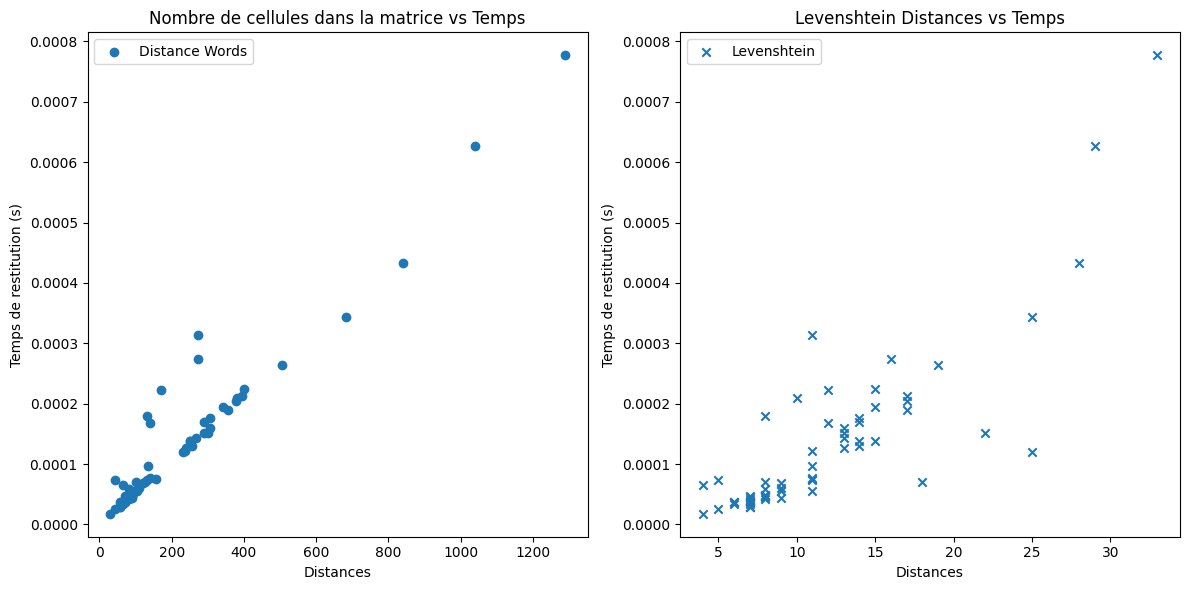

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))  

# Premier graphique 
axs[0].scatter(distances_words, restitutions_times_numpy, label="Distance Words", marker='o')
axs[0].set_xlabel('Distances')
axs[0].set_ylabel('Temps de restitution (s)')
axs[0].set_title('Nombre de cellules dans la matrice vs Temps')
axs[0].legend()

# Deuxième graphique 
axs[1].scatter(levenshtein_distances, restitutions_times_numpy, label="Levenshtein", marker='x')
axs[1].set_xlabel('Distances')
axs[1].set_ylabel('Temps de restitution (s)')
axs[1].set_title('Levenshtein Distances vs Temps')
axs[1].legend()

# Afficahge des graphes
plt.tight_layout() 
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    La longueur des mots et la distance de Levenshtein ont un grand impact sur le temps de restitution; PLus les mot sont longs, plus le nombre d'opérations à effectuer peut être long. Et si nous avons beaucoup d'opérations à affectuer cela prend plus de temps.
  </p>
  <p>
    Au de nos exemples, nous pouvons pu observer que pLus la longueur des deux mots est longue, et  la distance de levenshtein est grande, le temps de restitution est plus long. Avec une longueur des deux mots grande et une distance de levenshtein est petite, le temps de restitutionest petit car on a pas effectué beaucoup d'opérations.
  </p>
</div>


2. Sur la base du code existant écrire un version utilisant des dask array. 
Tester sur de petites séquences, observer le graphe des tâches et relever les temps de restitution.

In [9]:

def initialize_matrix_dask(s1, s2):
    """Initialisation de la matrice d'édition avec les bords (insertions/suppressions). avec dask"""
    m, n = len(s1), len(s2)

    # Création de la matrice principale
    dp = da.zeros((m+1, n+1), dtype=int)

    # Initialisation des bords (coûts d'insertion et suppression)
    dp[:, 0] = da.arange(m+1)  # Première colonne : Suppressions
    dp[0, :] = da.arange(n+1)  # Première ligne : Insertions

    return dp


def levenshtein_dask(s1, s2):
    """Calcul de la distance levenshtein."""
    dp = initialize_matrix_dask(s1, s2)  # Initialisation de la matrice
    fill_matrix(dp, s1, s2)         # Remplissage de la matrice
    
    return dp[len(s1), len(s2)]     # Retourne la distance finale

1


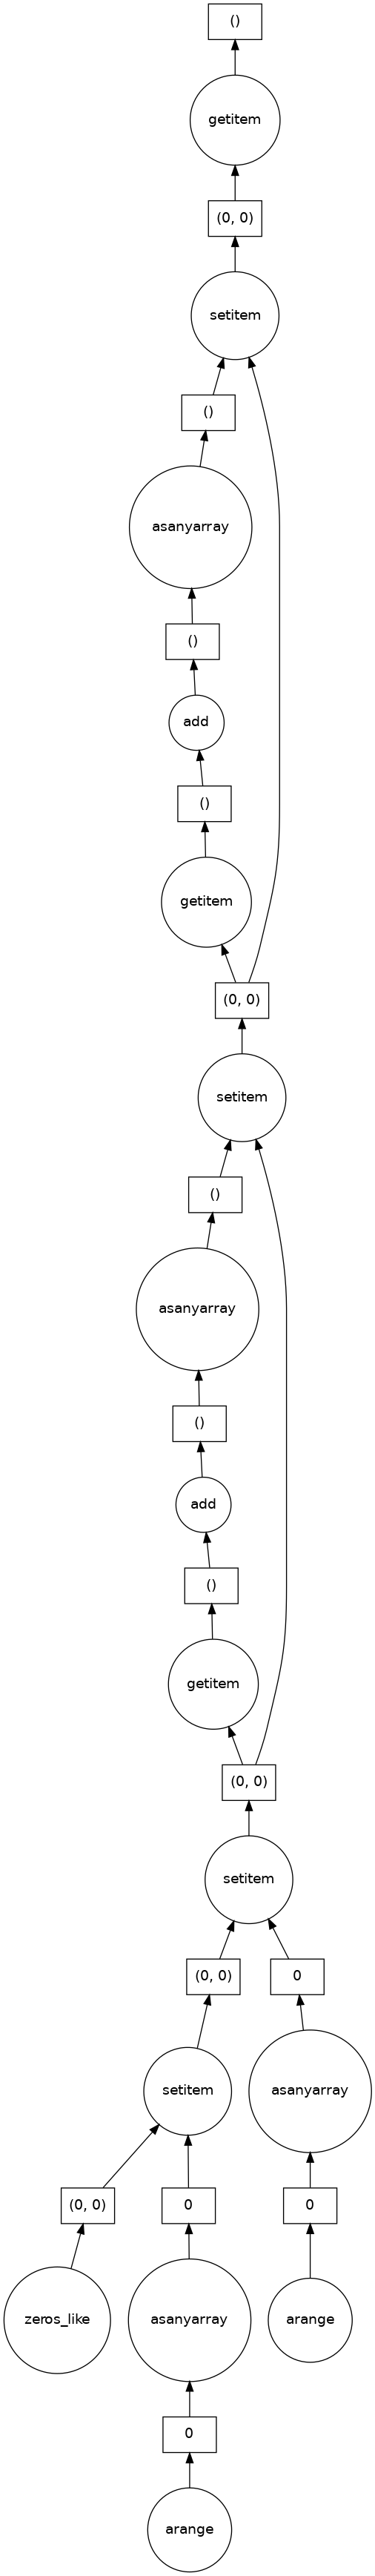

In [10]:
#test
s1 = "ha"
s2 = "a"
r = levenshtein_dask(s1, s2)
print(r.compute())  
levenshtein_dask(s1, s2).visualize()

In [11]:
sequences1 = [
    'GATTACA', 'flawn', 'sitting', 'saturday', 'elephant', 'marcy', 'rodrigo',
    'algorithm', 'basketball', 'chocolate', 'diamond', 'elephant', 'freedom', 
    'giraffe', 'happiness', 'illusion', 'jazz', 'kangaroo', 'lightning', 
    'mountain', 'notebook', 'octopus', 'penguin', 'quasar', 'butterfly', 
    'crocodile', 'dinosaur', 'fireworks', 'hamburger', 'kaleidoscope'
]

sequences2 = [
    'GCATGCU', 'drawn', 'kitten', 'sunday', 'relevant', 'andreina', 'gaston',
    'alligator', 'basket', 'caramel', 'dynamite', 'elephant', 'festival', 
    'guitar', 'harmony', 'imagination', 'jungle', 'koala', 'lighthouse', 
    'monument', 'notepad', 'ostrich', 'parrot', 'quicksand', 'buttercup', 
    'crocodile', 'dinosaur', 'firework', 'hamburgers', 'kaleidoscopes'
]

restitutions_times_numpy2 = [] #Tableau qui stocke le temps de restitution entre deux mots avec numpy
restitutions_times_dask1 = [] #Tableau qui stocke le temps de restitution entre deux mots sans la fonction compute
restitutions_times_dask2 = [] #Tableau qui stocke le temps de restitution entre deux mots avec la fonction compute
levenshtein_distances = [] #Tableau qui stocke la distance de Levenshtein entre deux mots
distances_words = [] #Tablau qui stocke ma matrice de cellules entre deux mots
for index,(mot1,mot2) in enumerate(zip(sequences1, sequences2)):
    tic = time.time()
    levenshtein_distance = levenshtein_dask(mot1, mot2)
    #levenshtein_distance.visualize()
    toc1 = time.time()
    temps = (toc1-tic)
    restitutions_times_dask1.append(temps)
    levenshtein_distances.append(levenshtein_distance.compute())
    toc2 =  time.time()
    temps = (toc2-tic)
    restitutions_times_dask2.append(temps)
    
    tic = time.time()
    levenshtein_distance = levenshtein_numpy(mot1, mot2)
    toc = time.time()
    temps = (toc-tic)
    restitutions_times_numpy2.append(temps)
    
    distances_words.append((len(mot1)+1)*(len(mot2)+1))
    

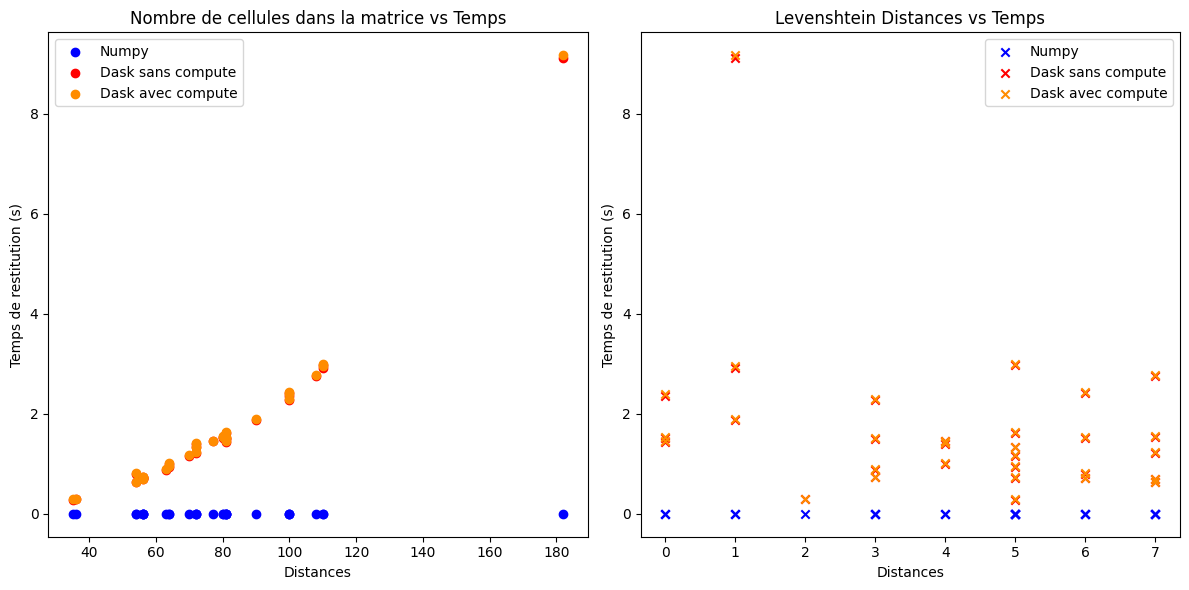

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))  

# Premier graphique 
axs[0].scatter(distances_words, restitutions_times_numpy2, label="Numpy", marker='o', color = "blue")
axs[0].scatter(distances_words, restitutions_times_dask1, label="Dask sans compute", marker='o', color = "red")
axs[0].scatter(distances_words, restitutions_times_dask2, label="Dask avec compute", marker='o', color = "darkorange")
axs[0].set_xlabel('Distances')
axs[0].set_ylabel('Temps de restitution (s)')
axs[0].set_title('Nombre de cellules dans la matrice vs Temps')
axs[0].legend()

# Deuxième graphique 
axs[1].scatter(levenshtein_distances, restitutions_times_numpy2, label="Numpy", marker='x', color = "blue")
axs[1].scatter(levenshtein_distances, restitutions_times_dask1, label="Dask sans compute", marker='x', color = "red")
axs[1].scatter(levenshtein_distances, restitutions_times_dask2, label="Dask avec compute", marker='x', color = "darkorange")
axs[1].set_xlabel('Distances')
axs[1].set_ylabel('Temps de restitution (s)')
axs[1].set_title('Levenshtein Distances vs Temps')
axs[1].legend()

# Afficahge des graphes
plt.tight_layout() 
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
      Dans cette partie, nous avons comparer les temps de restitution en utilisant trois approches: une version avec Numpy, avec version avec Dask sans la fonction compute, et une autre version avec Dask  avec compute
     </p> 
    La version utilisant dask prend plus de temps que celle avec Numpy. Et plus la longueur des mots est longue, le temps de restituion est long. Le graphe de calcul est très lourd à afficher lorsque la séquence des mots est très long, ce qui rend difficile l'analyse visuelle des performances.
  </p>
   <p>
    De plus, le temps de rendu avec la version Dask est plus long car Dask crée un graphique de tâches en divisant la matrice en parties individuelles, mais en raison de la méthode de remplissage de la matrice, il est nécessaire d'attendre le résultat d'une tâche pour commencer le calcul d'une autre.
   </p>
   <p>
    De plus, avec le calcul activé, nous déclenchons l'exécution réelle des calculs de distance de Levenshetein après la planification, ce qui augmente légèrement le temps de rendu. Alors, avec dask, il faudrait travailler sur des petites séquences de mots pour éviter la surcharge.
  </p>
</div>
 
 

## 2 Optimisations
1. Sur la base de la version numpy, écrire un algorithme non parallèle où la matrice principale est remplie en la parcourant par bloc de taille fixe (par exemple 100 $\times$ 100) : on remplit le premier bloc puis on passe au suivant ligne par ligne.

In [15]:
def fill_matrix_by_blocks(dp, s1, s2, block_size):
    """Remplissage de la matrice de Levenshtein par blocs de taille fixe."""
    m, n = len(s1), len(s2)
    
    # Remplissage de la matrice par blocs
    for i in range(1, m + 1, block_size):
        for j in range(1, n + 1, block_size):
            # Définir les limites du bloc
            i_end = min(i + block_size, m + 1)
            j_end = min(j + block_size, n + 1)
            
            # Remplir le bloc
            for row in range(i, i_end):
                for col in range(j, j_end):
                    cost = 0 if s1[row - 1] == s2[col - 1] else 1
                    dp[row, col] = min(
                        dp[row - 1, col] + 1,      # Suppression
                        dp[row, col - 1] + 1,      # Insertion
                        dp[row - 1, col - 1] + cost  # Substitution
                    )
    
    return dp
def levenshtein_numpy_block(s1, s2,block_size):
    """Calcul de la distance levenshtein."""
    dp = initialize_matrix(s1, s2)  # Initialisation de la matrice
    fill_matrix_by_blocks(dp, s1, s2,block_size)         # Remplissage de la matrice
   
    return dp[len(s1), len(s2)]     # Retourne la distance finale

2. Relever les temps de restitution.

In [20]:
sequences1 = [
    'GATTACA', 'flawn', 'sitting', 'saturday', 'elephant', 'encyclopedia', 'democracy', 'marcy', 'rodrigo',
    'pneumonoultramicroscopicsilicovolcanoconiosis', 'hepaticocholangiocholecystenterostomies', 
    'supercalifragilisticexpialidocious', 'pseudopseudohypoparathyroidism', 'floccinaucinihilipilification',
    'algorithm', 'basketball', 'chocolate', 'diamond', 'elephant', 'freedom', 'giraffe', 'happiness', 
    'illusion', 'jazz', 'kangaroo', 'lightning', 'mountain', 'notebook', 'octopus', 'penguin', 'quasar',
    'butterfly', 'crocodile', 'dinosaur', 'fireworks', 'hamburger', 'kaleidoscope', 'lighthouse', 
    'metamorphosis', 'nightingale', 'orchestra',
    'internationalization', 'confidentiality', 'incomprehensible', 'biodegradability', 'characterization', 
    'electromagnetic', 'industrialization', 'revolutionary', 'telecommunication', 'unpredictability',
    'counterrevolutionary', 'deinstitutionalization', 'electroencephalogram', 'institutionalization', 
    'overcommercialization', 'psychophysiological', 'radioimmunoassay', 'thermoluminescence', 
    'trichotillomania', 'uncharacteristically'
]

sequences2 = [
    'GCATGCU', 'kitten', 'sunday', 'relevant', 'psychoanalysis', 'aristocracy', 'andreina', 'gaston',
    'antidisestablishmentarianism', 'honorificabilitudinitatibus', 'thyroparathyroidectomized', 
    'dichlorodifluoromethane', 'incomprehensibilities', 'alligator', 'basket', 'caramel', 'dynamite', 
    'elephant', 'festival', 'guitar', 'harmony', 'imagination', 'jungle', 'koala', 'lighthouse', 'monument', 
    'notepad', 'ostrich', 'parrot', 'quicksand', 'buttercup', 'crocodile', 'dinosaur', 'firework', 
    'hamburgers', 'kaleidoscopes', 'lantern', 'metamorphic', 'nightmare', 'orchestral',
    'intercontinental', 'confidential', 'incomprehensibly', 'biodegradable', 'characteristic', 
    'electromagnetism', 'industrialized', 'revolutionize', 'telecommunications', 'unpredictable',
    'counterproductive', 'deinstitutionalize', 'electroencephalograph', 'institutionalize', 
    'overcommercialize', 'psychophysiologic', 'radioimmunological', 'thermoluminescent', 
    'trichotillomaniac', 'uncharacteristic', 'drawn'
]




block_sizes = [3,4,7,8,9,10,12,15]
for block_size in block_sizes:
    distances_words = [] #Tablau qui stocke ma matrice de cellules entre deux mots
    restitutions_times_numpy_block = [] #Tableau qui stocke le temps de restitution entre deux mots
    levenshtein_distances = [] #Tableau qui stocke la distance de Levenshtein entre deux mots
    for index,(mot1,mot2) in enumerate(zip(sequences1, sequences2)):
        #avec block
        tic = time.time()
        levenshtein_distance_block = levenshtein_numpy_block(mot1, mot2,block_size)
       
        toc =  time.time()
        temps = (toc-tic)
        restitutions_times_numpy_block.append(temps)

        distances_words.append((len(mot1)+1)*(len(mot2)+1))
        levenshtein_distances.append(levenshtein_distance_block)
    print(f"Temps moyen pour un bloc {block_size}x{block_size} : {np.mean(restitutions_times_numpy_block)*1000:.3}ms")
print(f"Temps moyen pour numpy sans bloc : {np.mean(restitutions_times_numpy)*1000:.3}ms")



Temps moyen pour un bloc 3*3 : 0.131ms
Temps moyen pour un bloc 4*4 : 0.132ms
Temps moyen pour un bloc 7*7 : 0.121ms
Temps moyen pour un bloc 8*8 : 0.114ms
Temps moyen pour un bloc 9*9 : 0.103ms
Temps moyen pour un bloc 10*10 : 0.106ms
Temps moyen pour un bloc 12*12 : 0.11ms
Temps moyen pour un bloc 15*15 : 0.102ms
Temps moyen pour numpy sans bloc : 0.135ms


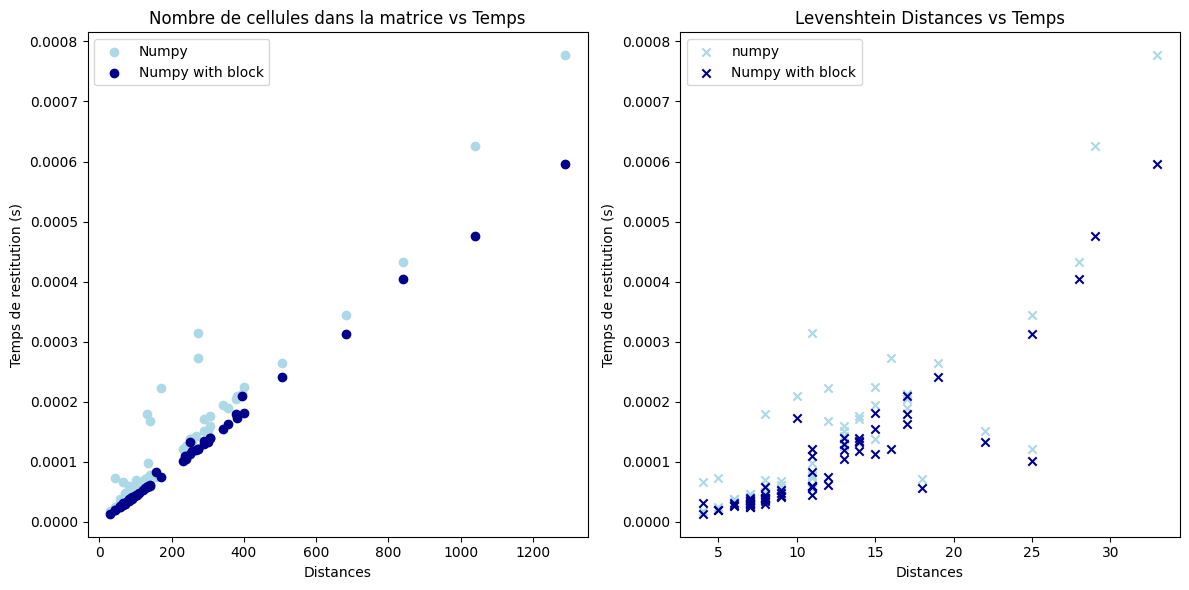

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))  

# Premier graphique 
axs[0].scatter(distances_words, restitutions_times_numpy, label="Numpy", marker='o', color="lightblue")
axs[0].scatter(distances_words, restitutions_times_numpy_block, label="Numpy with block", marker='o', color="darkblue")
axs[0].set_xlabel('Distances')
axs[0].set_ylabel('Temps de restitution (s)')
axs[0].set_title('Nombre de cellules dans la matrice vs Temps')
axs[0].legend()

# Deuxième graphique
axs[1].scatter(levenshtein_distances, restitutions_times_numpy, label="numpy", marker='x', color="lightblue")
axs[1].scatter(levenshtein_distances, restitutions_times_numpy_block, label="Numpy with block", marker='x', color="darkblue")
axs[1].set_xlabel('Distances')
axs[1].set_ylabel('Temps de restitution (s)')
axs[1].set_title('Levenshtein Distances vs Temps')
axs[1].legend()

# Afficahge des graphes
plt.tight_layout() 
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    En observant nos graphiques, nous voyons que la version avec les blocs prennent moins de temps que celle traitant intégralement la matrice. Le fait de diviser notre matrice en bloc de taille fixe permet de mieux gérer les calculs et d'optimiser les ressources. 
  </p>
  <p>
    De plus, en augmentant la taille des blocs, nous voyons que le temps de restitution diminue un peu moins. 
  </p>
</div>

3. Sur la base de cette version établir un algorithme parallèle et tenter de le mettre en oeuvre à l’aide de Dask array, pour cela regarder les méthodes `map_blocks` et `map_overlap`.

In [25]:
def initialize_matrix(s1, s2):
    """Initialise la matrice d'édition avec les coûts d'insertion et de suppression."""
    m, n = len(s1), len(s2)
    dp = np.zeros((m+1, n+1), dtype=int)
    dp[:, 0] = np.arange(m+1)
    dp[0, :] = np.arange(n+1)
    return da.from_array(dp, chunks=(min(100, m+1), min(100, n+1)))

def compute_block(block, s1=None, s2=None, block_offset=None):
    """Calculer un bloc de la matrice de Levenshtein."""
    max_int = np.iinfo(np.int32).max
    block_i, block_j = block_offset
    
    for i in range(block.shape[0]):
        for j in range(block.shape[1]):
            abs_i, abs_j = block_i + i, block_j + j
            if abs_i == 0 or abs_j == 0:
                continue
            
            cost = 0 if s1[abs_i-1] == s2[abs_j-1] else 1
            block[i, j] = min(
                block[i-1, j] + 1 if i > 0 else max_int,      # Suppression
                block[i, j-1] + 1 if j > 0 else max_int,      # Inserrtion
                block[i-1, j-1] + cost if i > 0 and j > 0 else max_int  # Substition
            )
    return block

def fill_matrix_parallel(dp, s1, s2, block_size=100):
    """Remplit la matrice de Levenshtein en parallèle avec Dask."""
    return dp.map_blocks(compute_block, dtype=int, s1=s1, s2=s2, block_offset=(0, 0))

def levenshtein_parallel(s1, s2, block_size=100):
    """Calcule la distance de Levenshtein en utilisant le remplissage de blocs parallèles """
    dp = initialize_matrix(s1, s2)
    dp = fill_matrix_parallel(dp, s1, s2, block_size)
    return dp.compute()[-1, -1]

4. Relever les temps de restitution

In [30]:
sequences1 = [
    'GATTACA', 'flawn', 'sitting', 'saturday', 'elephant', 'marcy', 'rodrigo',
    'algorithm', 'basketball', 'chocolate', 'diamond', 'elephant', 'freedom', 
    'giraffe', 'happiness', 'illusion', 'jazz', 'kangaroo', 'lightning', 
    'mountain', 'notebook', 'octopus', 'penguin', 'quasar', 'butterfly', 
    'crocodile', 'dinosaur', 'fireworks', 'hamburger', 'kaleidoscope'
]

sequences2 = [
    'GCATGCU', 'drawn', 'kitten', 'sunday', 'relevant', 'andreina', 'gaston',
    'alligator', 'basket', 'caramel', 'dynamite', 'elephant', 'festival', 
    'guitar', 'harmony', 'imagination', 'jungle', 'koala', 'lighthouse', 
    'monument', 'notepad', 'ostrich', 'parrot', 'quicksand', 'buttercup', 
    'crocodile', 'dinosaur', 'firework', 'hamburgers', 'kaleidoscopes'
]



restitutions_times_parallel = [] #Tableau qui stocke le temps de restitution entre deux mots sans la fonction compute
levenshtein_distances = [] #Tableau qui stocke la distance de Levenshtein entre deux mots
distances_words = [] #Tablau qui stocke ma matrice de cellules entre deux mots
restitutions_times_numpy_block2 = []
block_size = 15
for index,(mot1,mot2) in enumerate(zip(sequences1, sequences2)):
    tic = time.time()
    levenshtein_distance = levenshtein_parallel(mot1, mot2)
    toc = time.time()
    temps = (toc-tic)
    restitutions_times_parallel.append(temps)
    
    #Numpy avec block
    tic = time.time()
    levenshtein_distance_block = levenshtein_numpy_block(mot1, mot2,block_size)
       
    toc =  time.time()
    temps = (toc-tic)
    restitutions_times_numpy_block2.append(temps)
    levenshtein_distances.append(levenshtein_distance)
    distances_words.append((len(mot1)+1)*(len(mot2)+1))   

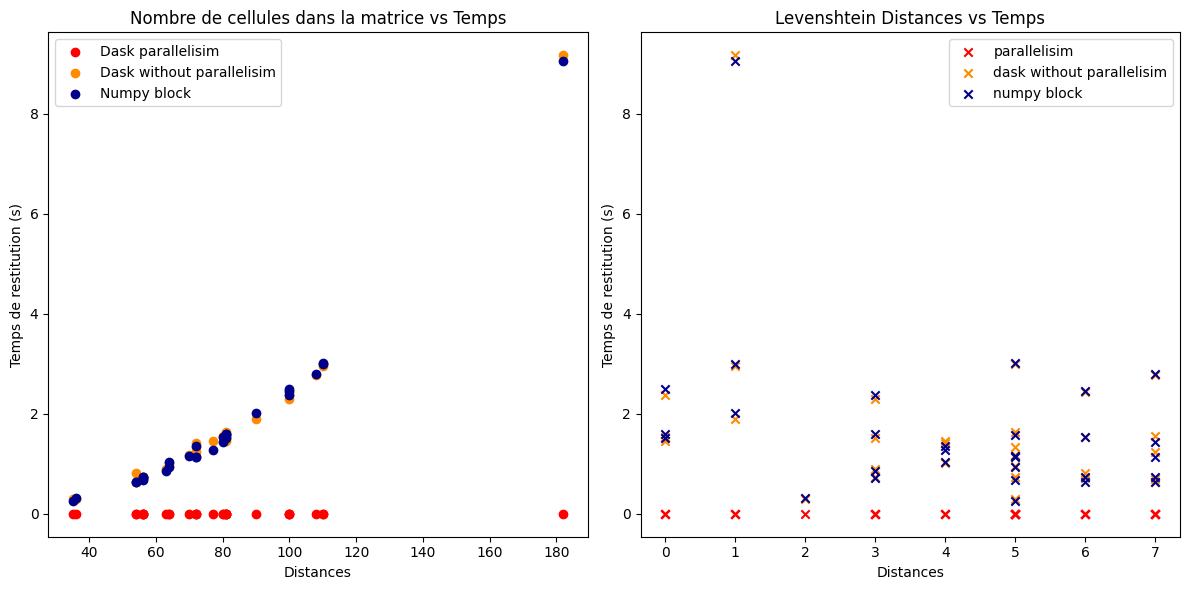

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))  

# Premier graphique 
axs[0].scatter(distances_words, restitutions_times_parallel, label="Dask parallelisim", marker='o', color="red")
axs[0].scatter(distances_words, restitutions_times_dask2, label="Dask without parallelisim", marker='o', color ="darkorange")
axs[0].scatter(distances_words, restitutions_times_numpy_block2, label="Numpy block", marker='o', color="darkblue")
axs[0].set_xlabel('Distances')
axs[0].set_ylabel('Temps de restitution (s)')
axs[0].set_title('Nombre de cellules dans la matrice vs Temps')
axs[0].legend()

# Deuxième graphique
axs[1].scatter(levenshtein_distances, restitutions_times_parallel, label="parallelisim", marker='x', color="red")
axs[1].scatter(levenshtein_distances, restitutions_times_dask2, label="dask without parallelisim", marker='x', color ="darkorange")
axs[1].scatter(levenshtein_distances, restitutions_times_numpy_block2, label="numpy block", marker='x', color="darkblue")
axs[1].set_xlabel('Distances')
axs[1].set_ylabel('Temps de restitution (s)')
axs[1].set_title('Levenshtein Distances vs Temps')
axs[1].legend()

# Afficahge des graphes
plt.tight_layout() 
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
En observant nos graphiques, nous constatons qu’en parallélisant le traitement des blocs de la matrice, le temps de restitution est considérablement réduit. Le fait de traiter les blocs en parallèle permet d'optimiser l'utilisation des ressources de calcul et d'accélérer le processus global.
  </p>
  <p>
    De plus, il existe une très grande différence de temps entre la version Dask parallélisée et la version Dask non parallélisée. Cette marge de temps est significative, ce qui montre clairement l'impact positif de la parallélisation.
</p>
    <p>
En résumé, les approches utilisant des blocs — notamment avec Numpy et Dask en parallèle — sont les plus efficaces et les plus rapides. Ces deux méthodes prennent moins de temps comparées aux autres approches, ce qui met en évidence l'importance de la parallélisation pour optimiser le calcul de la distance de Levenshtein.
  </p>
</div>